In [1]:
import cv2
from paddleocr import PaddleOCR

In [5]:
import re
import numpy as np
import json
import os
import time

**PURE OCR NO PIPELINE**

In [6]:
image_path="C:\ALL PROJECTS\MCCB-Defect-Detection\images\debug_layout\layout_masterP13P_mccb.png"
img=cv2.imread(image_path)


In [7]:
ocr=PaddleOCR(use_angle_cs=True,lang='en',show_log=False)

In [9]:
start_time=time.time()
results=ocr.ocr(img)
end_time=time.time()

[2026/02/20 09:20:42] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


In [11]:
lines=[]
if results is not None and len(results) > 0:
    for line in results[0]:
        text = line[1][0]          # Extract detected text
        confidence = line[1][1]    # Extract confidence score
        
        lines.append(text)

print(lines)

[' TABLE RO', '3', 'SACE FORMULA P1B 160', 'S/N:CFC6306263', 'Ue', 'Icu (kA)', 'Ui', 'Uimp', 'Ics (kA)', '220-240Vac', '25', '750V', '8kV', '25', '380-415Vac', '18', '18', 'HX', 'CAT.A', '15', 'IS/IEC 60947-2', '440Vac', '7.5', '8', '500Vac', '3', '3', '50-60Hz', '18', '250Vdc', '18', '-2Pin series', 'L-6200209088', 'Tested at415Vac', 'ABB', 'Formula DSP', 'SWITCH', 'P1B 160', 'IEC 60947-2', 'MADE IN INDIA', 'CE', 'TEST', 'x', 'In=100A', ' RATING', 'TMD', 'In=100A', 'MAX', 'MIN', '40C', 'MED', '100A', '85A', '1000A', '70A', '13', 'MAX', 'MED', 'MIN', 'FIXED', '6']


In [13]:
print(end_time-start_time)

4.527787685394287


**USED PIPELINE**

In [40]:
IMAGE_DIR="C:\ALL PROJECTS\MCCB-Defect-Detection\images\master_mccb"
DEBUG_DIR="C:\ALL PROJECTS\MCCB-Defect-Detection\images\master_mccb\debug_pipeline"

In [41]:
ocr = PaddleOCR(use_angle_cls=True, lang='en', show_log=False)

In [42]:
if not os.path.exists(DEBUG_DIR):
    os.makedirs(DEBUG_DIR)
# Get list of images
if os.path.exists(IMAGE_DIR):
    image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} images: {image_files}")
else:
    print(f"Directory '{IMAGE_DIR}' not found. Please create it and upload images.")
    image_files = []

Found 4 images: ['masterP13P_mccb.png', 'masterP14P_mccb.png', 'masterXT13P_mccb.png', 'masterXT14P_mccb.png']


In [ ]:
# Main code
import json

json_results = [] 

print(f"Starting execution on {len(image_files)} images...\n")

for filename in image_files:
    image_path = os.path.join(IMAGE_DIR, filename)
    print("="*60)
    print(f"PROCESSING: {filename}")
    
    # 1. LOAD IMAGE
    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    # 2. DETECT SWITCH
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    switch_contour = None
    max_area = 0
    switch_top_y = None
    
    for c in contours:
        area = cv2.contourArea(c)
        x, y, cw, ch = cv2.boundingRect(c)
        cx, cy = x + cw/2, y + ch/2
        
        # Check if it looks like a switch (center of image, large area)
        if (0.2 * w < cx < 0.8 * w) and (0.3 * h < cy < 0.8 * h) and (area > 5000):
            if area > max_area:
                max_area = area
                switch_contour = c
    
    # Define ROI boundaries based on switch position
    if switch_contour is not None:
        _, sy, _, sh = cv2.boundingRect(switch_contour)
        switch_top_y = sy
        table_y_min, table_y_max = int(h * 0.05), sy
        rating_y_min, rating_y_max = sy, int(h * 0.95)
        print(f"  [INFO] Switch anchor found at Y={sy}")
    else:
        table_y_min, table_y_max = 0, h
        rating_y_min, rating_y_max = 0, h
        print("  [WARN] Switch not found, defaulting to full image.")

    # 3. RUN OCR
    ocr_result = ocr.ocr(img, cls=True)
    if not ocr_result or ocr_result[0] is None:
        continue
    all_lines = ocr_result[0]
    
    # 4. EXTRACT DATA
    # A. Extract Rating
    rating_val = None
    rating_pattern = re.compile(r'(?:I|l|1)n\s*=\s*(\d+\s*A)', re.IGNORECASE)
    
    for line in all_lines:
        text = line[1][0]
        cy = sum([p[1] for p in line[0]]) / 4
        if rating_y_min < cy < rating_y_max:
            match = rating_pattern.search(text)
            if match:
                rating_val = match.group(0)
                break
    
    # B. Extract Table
    table_boxes = []
    for line in all_lines:
        text = line[1][0]
        box = line[0]
        cy = sum([p[1] for p in box]) / 4
        cx = sum([p[0] for p in box]) / 4
        
        if table_y_min < cy < table_y_max:
            table_boxes.append({"text": text, "cy": cy, "cx": cx, "h": abs(box[2][1] - box[0][1])})
            
    table_rows = []
    if table_boxes:
        table_boxes.sort(key=lambda k: k['cy'])
        current_row = []
        last_y = table_boxes[0]['cy']
        avg_h = np.mean([b['h'] for b in table_boxes])
        
        for item in table_boxes:
            if abs(item['cy'] - last_y) <= (avg_h * 0.6):
                current_row.append(item)
            else:
                current_row.sort(key=lambda k: k['cx'])
                table_rows.append([x['text'] for x in current_row])
                current_row = [item]
                last_y = item['cy']
        if current_row:
            current_row.sort(key=lambda k: k['cx'])
            table_rows.append([x['text'] for x in current_row])

    # 5. CONSTRUCT JSON OBJECT
    # Key-Value pair construction
    entry = {
        "filename": filename,
        "parameters": {
            "rated_current": rating_val if rating_val else "Not Found",
            # We can add more specific fields here later
        },
        "technical_table": table_rows
    }
    
    json_results.append(entry)
    print(f"  -> Extracted: {rating_val} | Table Rows: {len(table_rows)}")

Starting execution on 4 images...

PROCESSING: masterP13P_mccb.png
  [INFO] Switch anchor found at Y=1697
  -> Extracted: In=100A | Table Rows: 10
PROCESSING: masterP14P_mccb.png
  [INFO] Switch anchor found at Y=1696
  -> Extracted: In=63A | Table Rows: 9
PROCESSING: masterXT13P_mccb.png
  [INFO] Switch anchor found at Y=1695
  -> Extracted: In=63A | Table Rows: 8
PROCESSING: masterXT14P_mccb.png
  [INFO] Switch anchor found at Y=1699
  -> Extracted: In=40A | Table Rows: 8


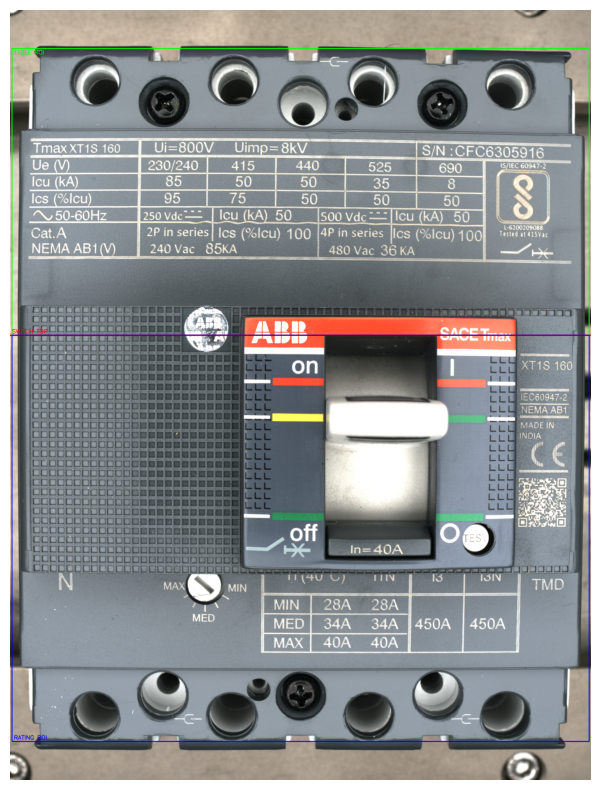

In [45]:
import matplotlib.pyplot as plt
if 'debug_path' in locals() and os.path.exists(debug_path):
    plt.figure(figsize=(10,10))
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    plt.imshow(cv2.cvtColor(cv2.imread(debug_path), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("No image processed yet.")

In [47]:
# Cell 6: Export to JSON
output_json_path = "ocr_results.json"

with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_results, f, ensure_ascii=False, indent=4)

print(f"JSON saved to: {output_json_path}")

# Print the first result to verify structure
if json_results:
    print("\nSample Output:")
    print(json.dumps(json_results[0], indent=4))

JSON saved to: ocr_results.json

Sample Output:
{
    "filename": "masterP13P_mccb.png",
    "parameters": {
        "rated_current": "In=100A"
    },
    "technical_table": [
        [
            "3"
        ],
        [
            "SACE FORMULA P1B 160",
            "S/NCFC6306263"
        ],
        [
            "Ue",
            "Icu (kA)",
            "Ics (kA)",
            "Ui",
            "Uimp"
        ],
        [
            "220-240Vac",
            "25",
            "25",
            "750V",
            "8kV"
        ],
        [
            "380-415Vac",
            "18",
            "18"
        ],
        [
            "440Vac",
            "15",
            "7.5",
            "CAT.A",
            "IS/IEC 60947-2"
        ],
        [
            "500Vac",
            "3",
            "3",
            "50-60Hz",
            "8"
        ],
        [
            "250Vdc",
            "18",
            "18",
            "2Pin series"
        ],
        [
            "T

In [48]:
# Cell 4: Main Processing Loop (Smart Field Extraction)
import json

json_results = [] 

print(f"Starting execution on {len(image_files)} images...\n")

for filename in image_files:
    image_path = os.path.join(IMAGE_DIR, filename)
    print("="*60)
    print(f"PROCESSING: {filename}")
    
    # 1. LOAD IMAGE
    img = cv2.imread(image_path)
    if img is None: continue
    h, w = img.shape[:2]

    # 2. DETECT SWITCH (Anchor)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 80, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    switch_contour = None
    max_area = 0
    switch_top_y = None
    
    for c in contours:
        area = cv2.contourArea(c)
        x, y, cw, ch = cv2.boundingRect(c)
        cx, cy = x + cw/2, y + ch/2
        if (0.2 * w < cx < 0.8 * w) and (0.3 * h < cy < 0.8 * h) and (area > 5000):
            if area > max_area:
                max_area = area
                switch_contour = c
    
    if switch_contour is not None:
        _, sy, _, sh = cv2.boundingRect(switch_contour)
        switch_top_y = sy
        table_y_min, table_y_max = int(h * 0.05), sy
        rating_y_min, rating_y_max = sy, int(h * 0.95)
    else:
        table_y_min, table_y_max = 0, h
        rating_y_min, rating_y_max = 0, h

    # 3. RUN OCR
    ocr_result = ocr.ocr(img, cls=True)
    if not ocr_result or ocr_result[0] is None: continue
    all_lines = ocr_result[0]
    
    # 4. EXTRACT SPECIFIC FIELDS
    # We will look for these keys in the text
    extracted_data = {
        "device_type": "Unknown",
        "serial_number": None,
        "rated_current": None,
        "voltage_ui": None,
        "voltage_uimp": None,
        "standard": None,
        "raw_table_content": [] # Keep raw lines just in case
    }
    
    # Regular Expressions for common fields
    patterns = {
        "serial_number": re.compile(r'S/N\s*[:\.]?\s*([A-Z0-9]+)', re.IGNORECASE),
        "voltage_ui": re.compile(r'Ui\s*[:=]?\s*(\d+\s*V)', re.IGNORECASE),
        "voltage_uimp": re.compile(r'Uimp\s*[:=]?\s*(\d+\s*kV)', re.IGNORECASE),
        "standard": re.compile(r'(IEC\s*60947-2|IS/IEC\s*60947-2)', re.IGNORECASE),
        "rated_current": re.compile(r'(?:I|l|1)n\s*=\s*(\d+\s*A)', re.IGNORECASE),
        "device_type": re.compile(r'(XT\d[A-Z]?\s*\d+|P[1-9][A-Z]\s*\d+)', re.IGNORECASE) # Matches XT1C 160 or P1B 160
    }

    # Iterate through all lines to find fields (Robust Search)
    for line in all_lines:
        text = line[1][0]
        box = line[0]
        cy = sum([p[1] for p in box]) / 4
        
        # --- A. RATING (Usually below switch) ---
        if rating_y_min < cy < rating_y_max:
            match = patterns["rated_current"].search(text)
            if match and not extracted_data["rated_current"]:
                extracted_data["rated_current"] = match.group(0)

        # --- B. TABLE AREA FIELDS (Top section) ---
        if table_y_min < cy < table_y_max:
            extracted_data["raw_table_content"].append(text)
            
            # Serial Number
            match = patterns["serial_number"].search(text)
            if match: extracted_data["serial_number"] = match.group(1)
            
            # Device Type (e.g., P1B 160, XT1 160)
            match = patterns["device_type"].search(text)
            if match: extracted_data["device_type"] = match.group(0)

            # Voltage Ui
            match = patterns["voltage_ui"].search(text)
            if match: extracted_data["voltage_ui"] = match.group(1)
            
            # Voltage Uimp
            match = patterns["voltage_uimp"].search(text)
            if match: extracted_data["voltage_uimp"] = match.group(1)

            # Standard
            match = patterns["standard"].search(text)
            if match: extracted_data["standard"] = match.group(0)

    # 5. CONSTRUCT CLEAN JSON
    entry = {
        "filename": filename,
        "common_parameters": {
            "device_model": extracted_data["device_type"],
            "serial_number": extracted_data["serial_number"] if extracted_data["serial_number"] else "Not Found",
            "rated_current": extracted_data["rated_current"] if extracted_data["rated_current"] else "Not Found",
            "ui": extracted_data["voltage_ui"],
            "uimp": extracted_data["voltage_uimp"],
            "standard": extracted_data["standard"]
        },
        "raw_text_lines": extracted_data["raw_table_content"] # Optional: keep raw extracted text
    }
    
    json_results.append(entry)
    
    # Print Summary for verification
    print(f"  -> Model: {extracted_data['device_type']}")
    print(f"  -> S/N:   {extracted_data['serial_number']}")
    print(f"  -> In:    {extracted_data['rated_current']}")

Starting execution on 4 images...

PROCESSING: masterP13P_mccb.png
  -> Model: P1B 160
  -> S/N:   CFC6306263
  -> In:    In=100A
PROCESSING: masterP14P_mccb.png
  -> Model: P1N 160
  -> S/N:   CFC6305002
  -> In:    In=63A
PROCESSING: masterXT13P_mccb.png
  -> Model: XT1C 160
  -> S/N:   CFC6305117
  -> In:    In=63A
PROCESSING: masterXT14P_mccb.png
  -> Model: XT1S 160
  -> S/N:   CFC6305916
  -> In:    In=40A


In [49]:
# Cell 5: Save JSON
output_path = "ocr_results_structured.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(json_results, f, indent=4)

print(f"Saved structured results to {output_path}")

# Display Sample
if json_results:
    print(json.dumps(json_results[0], indent=4))

Saved structured results to ocr_results_structured.json
{
    "filename": "masterP13P_mccb.png",
    "common_parameters": {
        "device_model": "P1B 160",
        "serial_number": "CFC6306263",
        "rated_current": "In=100A",
        "ui": null,
        "uimp": null,
        "standard": "IS/IEC 60947-2"
    },
    "raw_text_lines": [
        "3",
        "SACE FORMULA P1B 160",
        "S/NCFC6306263",
        "Ue",
        "Icu (kA)",
        "Uimp",
        "Ics (kA)",
        "Ui",
        "220-240Vac",
        "25",
        "750V",
        "25",
        "8kV",
        "380-415Vac",
        "18",
        "18",
        "CAT.A",
        "15",
        "IS/IEC 60947-2",
        "440Vac",
        "7.5",
        "8",
        "500Vac",
        "3",
        "3",
        "50-60Hz",
        "250Vdc",
        "18",
        "18",
        "2Pin series",
        "Tested at415Vac",
        "ABB",
        "|Formula DSP"
    ]
}
